# The Impact of Judgment Calls in Data Science
## A Many Analysts Case Study: Soccer Referee Bias

### Background

Silberzahn et al. (2018) conducted a experiment: they gave **29 independent research teams** the **same dataset** and asked them all to answer the **same research question**:

> **Are soccer referees more likely to give red cards to dark-skinned players than light-skinned players?**

All teams had access to:
- The same raw data (146,028 player-referee interactions)
- The same data documentation
- The same research question

### What happened?

The results varied dramatically:
- **20 teams** found a statistically significant positive relationship (dark-skinned players get more red cards)
- **9 teams** found no significant relationship
- Effect sizes ranged from odds ratios of 1.04 to 2.93

### Why did results differ?

Each team made different **judgment calls** about:
- How to clean the data (which observations to exclude?)
- How to construct variables (how to measure skin tone? how to measure red cards?)
- What statistical model to use
- What control variables to include

### Today's Activity

You'll walk through this analysis yourself and see how **small, reasonable decisions** can lead to **different conclusions**. This demonstrates why it's crucial to:
1. **Think carefully** about every decision in your analysis
2. **Document** your decisions
3. **Test** how sensitive your results are to different choices
4. **Be transparent** about the choices you made

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

# set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# load the data
df_raw = pd.read_csv("data/soccer.csv")
print(f"Raw dataset: {len(df_raw):,} player-referee dyads")
df_raw.head()

Raw dataset: 146,028 player-referee dyads


,playerShort,player,club,leagueCountry,birthday,height,weight,position,games,victories,ties,defeats,goals,yellowCards,yellowReds,redCards,photoID,rater1,rater2,refNum,refCountry,Alpha_3,meanIAT,nIAT,seIAT,meanExp,nExp,seExp
0,lucas-wilchez,Lucas Wilchez,Real Zaragoza,Spain,31.08.1983,177.0,72.0,Attacking Midfielder,1,0,0,1,0,0,0,0,95212.jpg,0.25,0.50,1,1,GRC,0.326391,712.0,0.000564,0.396000,750.0,0.002696
1,john-utaka,John Utaka,Montpellier HSC,France,08.01.1982,179.0,82.0,Right Winger,1,0,0,1,0,1,0,0,1663.jpg,0.75,0.75,2,2,ZMB,0.203375,40.0,0.010875,-0.204082,49.0,0.061504
2,abdon-prats,Abdón Prats,RCD Mallorca,Spain,17.12.1992,181.0,79.0,NaN,1,0,1,0,0,1,0,0,NaN,NaN,NaN,3,3,ESP,0.369894,1785.0,0.000229,0.588297,1897.0,0.001002
3,pablo-mari,Pablo Marí,RCD Mallorca,Spain,31.08.1993,191.0,87.0,Center Back,1,1,0,0,0,0,0,0,NaN,NaN,NaN,3,3,ESP,0.369894,1785.0,0.000229,0.588297,1897.0,0.001002
4,ruben-pena,Rubén Peña,Real Valladolid,Spain,18.07.1991,172.0,70.0,Right Midfielder,1,1,0,0,0,0,0,0,NaN,NaN,NaN,3,3,ESP,0.369894,1785.0,0.000229,0.588297,1897.0,0.001002


## Part 1: Understanding the Data

### Data Structure

The data is at the **player-referee dyad** level. Each row represents:
- One player
- One referee
- All the games they encountered each other

### Key Variables

**Outcome:**
- `redCards`: Number of red cards this player received from this referee
- `yellowCards`: Number of yellow cards received

**Key Predictor:**
- `rater1`, `rater2`: Skin tone ratings (0.0 = very light, 0.25 = light, 0.5 = neither, 0.75 = dark, 1.0 = very dark)

**Player characteristics:**
- `games`: Number of games this player-referee pair encountered each other
- `height`, `weight`: Player physical characteristics
- `position`: Player position
- `leagueCountry`: Which country's league (England, Germany, France, Spain)

**Referee characteristics:**
- `meanIAT`: Implicit bias score for referee's country
- `meanExp`: Explicit bias score for referee's country

Let's explore:

In [ ]:
# how many unique players and referees?
print(f"Unique players: {df_raw['playerShort'].nunique():,}")
print(f"Unique referees: {df_raw['refNum'].nunique():,}")
print()

# missing skin tone ratings
print(f"Players with rater1 data: {df_raw['rater1'].notna().sum():,} / {len(df_raw):,}")
print(f"Players with rater2 data: {df_raw['rater2'].notna().sum():,} / {len(df_raw):,}")
print()

# distribution of games per dyad
print("Games per player-referee dyad:")
print(df_raw['games'].describe())

Unique players: 2,053
Unique referees: 3,147

Players with rater1 data: 124,621 / 146,028
Players with rater2 data: 124,621 / 146,028

Games per player-referee dyad:
count    146028.000000
mean          2.921166
std           3.413633
min           1.000000
25%           1.000000
50%           2.000000
75%           3.000000
max          47.000000
Name: games, dtype: float64


In [ ]:
# distribution of red cards
print("Red cards distribution (at dyad level):")
print(df_raw['redCards'].value_counts().sort_index())
print()
print(f"Dyads with at least one red card: {(df_raw['redCards'] > 0).sum():,} ({(df_raw['redCards'] > 0).mean()*100:.1f}%)")

Red cards distribution (at dyad level):
redCards
0    144219
1      1784
2        25
Name: count, dtype: int64

Dyads with at least one red card: 1,809 (1.2%)


## Part 2: The First Major Decision - Unit of Analysis

### Decision #1: What level should we analyze?

The data is at the **player-referee dyad** level, but we could analyze at different levels:

**Option A: Player-Referee Dyad Level** (keep as is)
- Each row is a player-referee pair
- Pro: Uses all available information
- Con: Same player appears many times (violates independence assumption)

**Option B: Player Level** (aggregate up)
- Combine all of a player's experiences across all referees
- Pro: Each player appears once (cleaner for basic analysis)
- Con: Loses information about specific referees

Most teams chose **Option B** for simplicity. Let's do that:

In [4]:
def aggregate_to_player_level(df):
    """
    Aggregate player-referee dyads to player level.
    Sum cards and games, average other continuous variables.
    """
    agg_dict = {
        'redCards': 'sum',
        'yellowCards': 'sum',
        'games': 'sum',
        'rater1': 'mean',
        'rater2': 'mean',
        'height': 'mean',
        'weight': 'mean',
        'position': 'first',
        'leagueCountry': 'first'
    }
    return df.groupby('playerShort').agg(agg_dict)

df_player = aggregate_to_player_level(df_raw)
print(f"Player-level dataset: {len(df_player):,} unique players")
df_player.head()

Player-level dataset: 2,053 unique players


,redCards,yellowCards,games,rater1,rater2,height,weight,position,leagueCountry
playerShort,,,,,,,,,
aaron-hughes,0,19,654,0.25,0.00,182.0,71.0,Center Back,England
aaron-hunt,1,42,336,0.00,0.25,183.0,73.0,Attacking Midfielder,Germany
aaron-lennon,0,11,412,0.25,0.25,165.0,63.0,Right Midfielder,England
aaron-ramsey,1,31,260,0.00,0.00,178.0,76.0,Center Midfielder,England
abdelhamid-el-kaoutari,2,8,124,0.25,0.25,180.0,73.0,Center Back,France


## Part 3: Data Cleaning Decisions

Now comes the critical part: **which observations should we keep?**

Different teams made different choices. Let's explore some key decisions:

### Decision #2: Missing Skin Tone Ratings

Some players don't have skin tone ratings (no photo available, or raters couldn't agree).

**Question:** Should we exclude these players?

- **Argument for excluding:** We can't answer the research question without knowing skin tone!
- **Argument for including:** Excluding might introduce bias (what if missingness is related to our outcome?)

Let's see how many we'd lose:

In [ ]:
print("Missing data patterns:")
print(f"Players with rater1 data: {df_player['rater1'].notna().sum():,} / {len(df_player):,}")
print(f"Players with rater2 data: {df_player['rater2'].notna().sum():,} / {len(df_player):,}")
print(f"Players with BOTH raters: {(df_player['rater1'].notna() & df_player['rater2'].notna()).sum():,} / {len(df_player):,}")
print(f"Players with AT LEAST ONE rater: {(df_player['rater1'].notna() | df_player['rater2'].notna()).sum():,} / {len(df_player):,}")

# for this analysis, we'll require at least one rater
# (this was a common choice among teams)

Missing data patterns:
Players with rater1 data: 1,585 / 2,053
Players with rater2 data: 1,585 / 2,053
Players with BOTH raters: 1,585 / 2,053
Players with AT LEAST ONE rater: 1,585 / 2,053


### Decision #3: Combining Rater Scores

We have two independent raters. How should we combine them?

**Option A:** Average the two ratings
- Simple, uses all available information
- What if raters disagree?

**Option B:** Only use players where raters agree exactly
- Higher confidence in skin tone measurement
- Loses a lot of data

**Option C:** Use rater1 only (or rater2 only)
- Simple, consistent
- Ignores the second rater's information

Let's see rater agreement:

Players rated by both: 1,585

Exact agreement: 1,206 (76.1%)
Within 0.25 points: 1,583 (99.9%)

Correlation between raters: 0.924


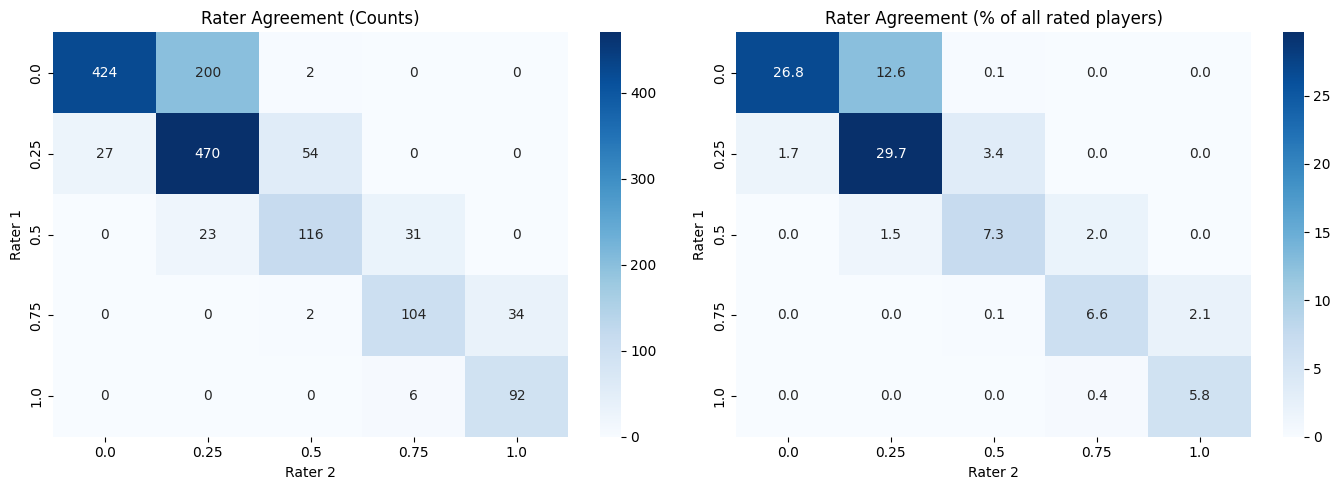

In [ ]:
# look at rater agreement
both_rated = df_player.dropna(subset=['rater1', 'rater2'])
print(f"Players rated by both: {len(both_rated):,}")
print()

# exact agreement
print(f"Exact agreement: {(both_rated['rater1'] == both_rated['rater2']).sum():,} ({(both_rated['rater1'] == both_rated['rater2']).mean()*100:.1f}%)")
print(f"Within 0.25 points: {(abs(both_rated['rater1'] - both_rated['rater2']) <= 0.25).sum():,} ({(abs(both_rated['rater1'] - both_rated['rater2']) <= 0.25).mean()*100:.1f}%)")
print()

# correlation
print(f"Correlation between raters: {both_rated['rater1'].corr(both_rated['rater2']):.3f}")

# heatmap of agreement
labels = [0.0, 0.25, 0.5, 0.75, 1.0]
confusion = pd.crosstab(both_rated['rater1'], both_rated['rater2'])
# reindex to ensure all categories are present
confusion = confusion.reindex(index=labels, columns=labels, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# counts heatmap
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=labels, yticklabels=labels)
axes[0].set_xlabel('Rater 2')
axes[0].set_ylabel('Rater 1')
axes[0].set_title('Rater Agreement (Counts)')

# proportions heatmap
confusion_pct = confusion / confusion.values.sum() * 100
sns.heatmap(confusion_pct, annot=True, fmt='.1f', cmap='Blues', ax=axes[1],
            xticklabels=labels, yticklabels=labels)
axes[1].set_xlabel('Rater 2')
axes[1].set_ylabel('Rater 1')
axes[1].set_title('Rater Agreement (% of all rated players)')

plt.tight_layout()
plt.show()

### Decision #4: Goalkeepers

Goalkeepers rarely receive red cards (they're far from the action).

**Question:** Should we exclude them?

- **Argument for excluding:** They're fundamentally different; including them adds noise
- **Argument for including:** They're still soccer players; excluding reduces generalizability

Let's investigate:

In [ ]:
# position distribution
print("Players by position:")
print(df_player['position'].value_counts())
print()

# red cards by position
print("Average red cards by position:")
position_summary = df_player.groupby('position')['redCards'].agg(['count', 'mean', 'sum'])
position_summary = position_summary.sort_values('mean', ascending=False)
print(position_summary)

Players by position:
position
Center Back             281
Center Forward          227
Defensive Midfielder    204
Goalkeeper              196
Attacking Midfielder    149
Left Fullback           136
Right Fullback          126
Left Midfielder          86
Center Midfielder        84
Right Midfielder         75
Right Winger             63
Left Winger              59
Name: count, dtype: int64

Average red cards by position:
                      count      mean  sum
position                                  
Center Back             281  1.583630  445
Right Winger             63  1.015873   64
Left Fullback           136  1.000000  136
Defensive Midfielder    204  0.980392  200
Left Midfielder          86  0.906977   78
Center Midfielder        84  0.904762   76
Center Forward          227  0.863436  196
Right Fullback          126  0.849206  107
Goalkeeper              196  0.795918  156
Left Winger              59  0.661017   39
Attacking Midfielder    149  0.624161   93
Right Midfielder 

### Decision #5: Players with Few Games

Some players only played a few games. Should we exclude them?

**Arguments:**
- **For excluding:** More reliable estimates from players with more games
- **Against excluding:** Loses data, might introduce bias

**If excluding, what's the threshold?** 10 games? 20? 50?

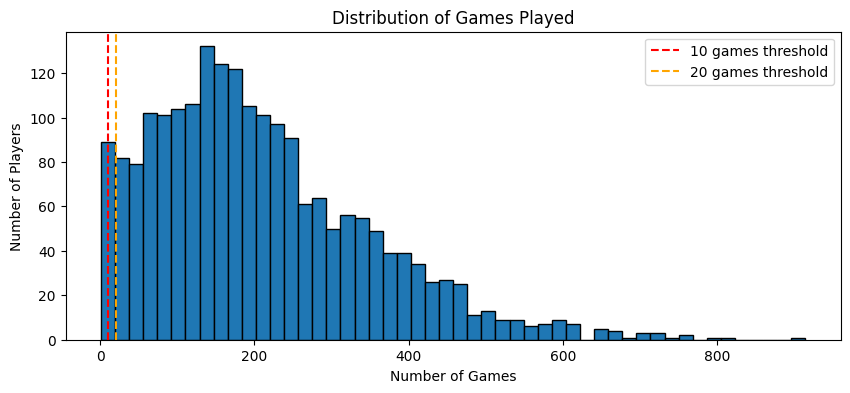

Players by games threshold:
  >=  0 games: 2,053 players (100.0%)
  >=  5 games: 2,015 players ( 98.1%)
  >= 10 games: 1,995 players ( 97.2%)
  >= 15 games: 1,979 players ( 96.4%)
  >= 20 games: 1,964 players ( 95.7%)
  >= 50 games: 1,828 players ( 89.0%)


In [ ]:
# games distribution
plt.figure(figsize=(10, 4))
plt.hist(df_player['games'], bins=50, edgecolor='black')
plt.xlabel('Number of Games')
plt.ylabel('Number of Players')
plt.title('Distribution of Games Played')
plt.axvline(10, color='red', linestyle='--', label='10 games threshold')
plt.axvline(20, color='orange', linestyle='--', label='20 games threshold')
plt.legend()
plt.show()

print("Players by games threshold:")
for threshold in [0, 5, 10, 15, 20, 50]:
    n = (df_player['games'] >= threshold).sum()
    pct = n / len(df_player) * 100
    print(f"  >= {threshold:2d} games: {n:4,} players ({pct:5.1f}%)")

## Part 4: Variable Construction Decisions (5 minutes)

### Decision #6: How to Measure Skin Tone?

Given our decision about combining raters, let's create our skin tone variable:

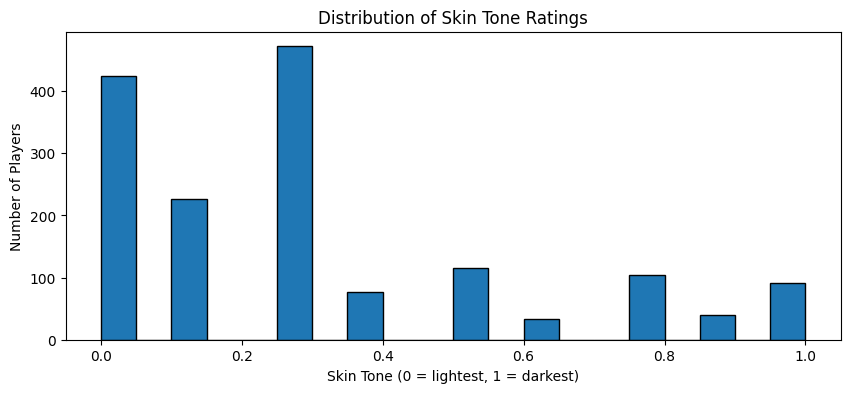

Skin tone summary:
count    1585.000000
mean        0.289511
std         0.290899
min         0.000000
25%         0.000000
50%         0.250000
75%         0.375000
max         1.000000
Name: skin_tone, dtype: float64


In [ ]:
# most teams averaged the two raters
df_player['skin_tone'] = df_player[['rater1', 'rater2']].mean(axis=1)

# visualize the distribution
plt.figure(figsize=(10, 4))
plt.hist(df_player['skin_tone'].dropna(), bins=20, edgecolor='black')
plt.xlabel('Skin Tone (0 = lightest, 1 = darkest)')
plt.ylabel('Number of Players')
plt.title('Distribution of Skin Tone Ratings')
plt.show()

print(f"Skin tone summary:")
print(df_player['skin_tone'].describe())

### Decision #7: How to Measure Red Cards?

We could use:

**Option A:** Raw count of red cards
- Pro: Simple, direct
- Con: Players with more games have more opportunities for red cards

**Option B:** Red cards per game (rate)
- Pro: Accounts for exposure/opportunity
- Con: Very skewed (most players have 0)

**Option C:** Binary (any red card: yes/no)
- Pro: Simple, robust to outliers
- Con: Loses information about severity

**Option D:** Log transformation of count
- Pro: Reduces skewness
- Con: Hard to interpret

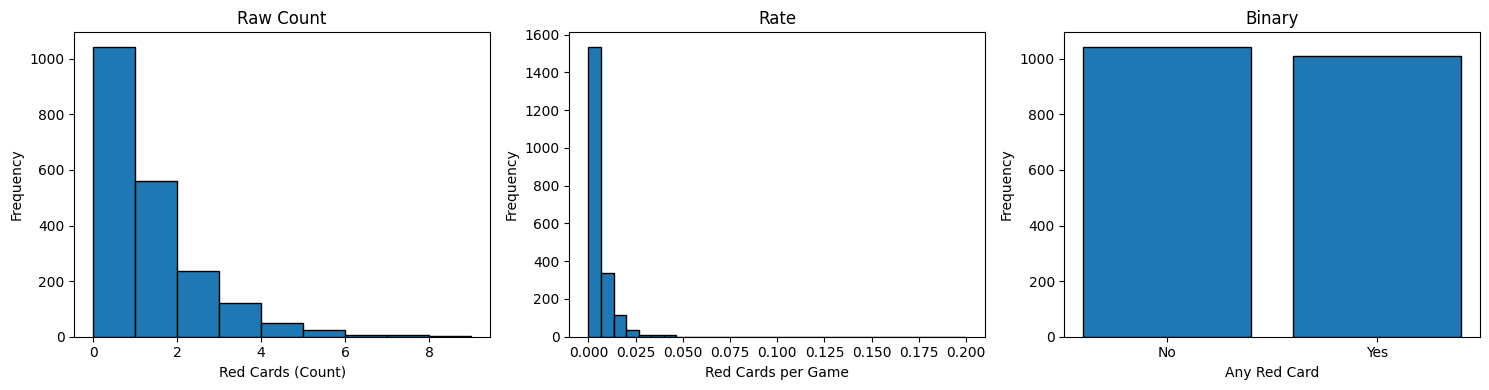

Players with at least one red card: 1,010 (49.2%)


In [ ]:
# create different outcome variables
df_player['red_card_rate'] = df_player['redCards'] / df_player['games']
df_player['any_red_card'] = (df_player['redCards'] > 0).astype(int)

# compare distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df_player['redCards'], bins=range(0, 10), edgecolor='black')
axes[0].set_xlabel('Red Cards (Count)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Raw Count')

axes[1].hist(df_player['red_card_rate'].dropna(), bins=30, edgecolor='black')
axes[1].set_xlabel('Red Cards per Game')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Rate')

axes[2].bar([0, 1], df_player['any_red_card'].value_counts().sort_index(), edgecolor='black')
axes[2].set_xlabel('Any Red Card')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Binary')
axes[2].set_xticks([0, 1])
axes[2].set_xticklabels(['No', 'Yes'])

plt.tight_layout()
plt.show()

print(f"Players with at least one red card: {df_player['any_red_card'].sum():,} ({df_player['any_red_card'].mean()*100:.1f}%)")

## Part 5: YOUR TURN - Make Your Choices and See Results! (15 minutes)

Now it's time for you to be the analyst! You'll make your own judgment calls and see how they affect the results.

### Your Task:

1. **Make your decisions** by setting the parameters below
2. **Run the analysis** to see your results
3. **Try different combinations** to see how sensitive the results are
4. **Compare with your classmates** - did you get the same answer?

### Instructions:

Modify the parameters in the cell below, then run all the subsequent cells to see your results.

In [11]:
# ========================================
# YOUR JUDGMENT CALLS - MODIFY THESE!
# ========================================

# Decision 1: Exclude goalkeepers?
EXCLUDE_GOALKEEPERS = True  # Try: True or False

# Decision 2: Minimum number of games?
MIN_GAMES = 10  # Try: 0, 5, 10, 15, 20, or 50

# Decision 3: Require both raters to have data?
REQUIRE_BOTH_RATERS = False  # Try: True or False

# Decision 4: Which outcome variable?
OUTCOME = 'red_card_rate'  # Try: 'redCards', 'red_card_rate', or 'any_red_card'

# Decision 5: Control for position?
CONTROL_POSITION = True  # Try: True or False

# Decision 6: Control for league country?
CONTROL_LEAGUE = True  # Try: True or False

# Decision 7: Control for physical characteristics?
CONTROL_PHYSICAL = False  # Try: True or False

In [ ]:
# apply your choices to create the analysis dataset
df_analysis = df_player.copy()

# track what we're doing
exclusion_reasons = {}
original_n = len(df_analysis)

print("Applying your judgment calls...")
print(f"Starting with {original_n:,} players\n")

# Decision 1: Goalkeepers
if EXCLUDE_GOALKEEPERS:
    before = len(df_analysis)
    df_analysis = df_analysis[df_analysis['position'] != 'Goalkeeper']
    excluded = before - len(df_analysis)
    exclusion_reasons['Goalkeepers'] = excluded
    print(f"Excluded {excluded:,} goalkeepers")

# Decision 2: Minimum games
if MIN_GAMES > 0:
    before = len(df_analysis)
    df_analysis = df_analysis[df_analysis['games'] >= MIN_GAMES]
    excluded = before - len(df_analysis)
    exclusion_reasons[f'< {MIN_GAMES} games'] = excluded
    print(f"Excluded {excluded:,} players with < {MIN_GAMES} games")

# Decision 3: Both raters
if REQUIRE_BOTH_RATERS:
    before = len(df_analysis)
    df_analysis = df_analysis.dropna(subset=['rater1', 'rater2'])
    excluded = before - len(df_analysis)
    exclusion_reasons['Missing rater'] = excluded
    print(f"Excluded {excluded:,} players missing a rater")
else:
    before = len(df_analysis)
    df_analysis = df_analysis.dropna(subset=['skin_tone'])
    excluded = before - len(df_analysis)
    exclusion_reasons['No skin tone data'] = excluded
    print(f"Excluded {excluded:,} players with no skin tone data")

print(f"\nFinal analysis sample: {len(df_analysis):,} players")
print(f"Excluded {original_n - len(df_analysis):,} players total ({(original_n - len(df_analysis))/original_n*100:.1f}%)")

Applying your judgment calls...
Starting with 2,053 players

Excluded 196 goalkeepers
Excluded 46 players with < 10 games
Excluded 399 players with no skin tone data

Final analysis sample: 1,412 players
Excluded 641 players total (31.2%)


In [ ]:
# build the regression formula based on your choices
formula_parts = [OUTCOME + ' ~ skin_tone']

# add control variables based on choices
if CONTROL_POSITION:
    formula_parts.append('C(position)')
if CONTROL_LEAGUE:
    formula_parts.append('C(leagueCountry)')
if CONTROL_PHYSICAL:
    formula_parts.append('height + weight')

formula = ' + '.join(formula_parts)
print("Your regression formula:")
print(f"  {formula}\n")

# drop any remaining missing values for the analysis
analysis_vars = ['skin_tone', OUTCOME]
if CONTROL_POSITION:
    analysis_vars.append('position')
if CONTROL_LEAGUE:
    analysis_vars.append('leagueCountry')
if CONTROL_PHYSICAL:
    analysis_vars.extend(['height', 'weight'])

df_final = df_analysis.dropna(subset=analysis_vars)
print(f"Final sample size (after removing missing controls): {len(df_final):,} players")

Your regression formula:
  red_card_rate ~ skin_tone + C(position) + C(leagueCountry)

Final sample size (after removing missing controls): 1,267 players


In [ ]:
# run the regression
if OUTCOME == 'any_red_card':
    # logistic regression for binary outcome
    model = smf.logit(formula, data=df_final).fit()
else:
    # OLS regression for continuous outcome
    model = smf.ols(formula, data=df_final).fit()

# Display results
print("="*80)
print("YOUR RESULTS")
print("="*80)
print(model.summary())

YOUR RESULTS
                            OLS Regression Results                            
Dep. Variable:          red_card_rate   R-squared:                       0.094
Model:                            OLS   Adj. R-squared:                  0.084
Method:                 Least Squares   F-statistic:                     9.308
Date:                Thu, 12 Feb 2026   Prob (F-statistic):           8.02e-20
Time:                        21:19:23   Log-Likelihood:                 4813.7
No. Observations:                1267   AIC:                            -9597.
Df Residuals:                    1252   BIC:                            -9520.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------

In [ ]:
# extract and display the key finding
skin_tone_coef = model.params['skin_tone']
skin_tone_pval = model.pvalues['skin_tone']
skin_tone_se = model.bse['skin_tone']

print("\n" + "="*80)
print("KEY FINDING: Effect of Skin Tone on Red Cards")
print("="*80)
print(f"Coefficient: {skin_tone_coef:.4f}")
print(f"Std Error:   {skin_tone_se:.4f}")
print(f"P-value:     {skin_tone_pval:.4f}")
print()

if skin_tone_pval < 0.05:
    print("✓ STATISTICALLY SIGNIFICANT at p < 0.05")
    if skin_tone_coef > 0:
        print("  Dark-skinned players receive MORE red cards")
    else:
        print("  Dark-skinned players receive FEWER red cards")
else:
    print("✗ NOT statistically significant at p < 0.05")
    print("  No evidence of a relationship between skin tone and red cards")

print()
if OUTCOME == 'any_red_card':
    odds_ratio = np.exp(skin_tone_coef)
    print(f"Interpretation: Moving from lightest (0) to darkest (1) skin tone")
    print(f"  multiplies the ODDS of receiving a red card by {odds_ratio:.2f}")
elif OUTCOME == 'red_card_rate':
    print(f"Interpretation: Moving from lightest (0) to darkest (1) skin tone")
    print(f"  changes red card rate by {skin_tone_coef:.4f} cards per game")
else:
    print(f"Interpretation: Moving from lightest (0) to darkest (1) skin tone")
    print(f"  changes expected red cards by {skin_tone_coef:.2f}")


KEY FINDING: Effect of Skin Tone on Red Cards
Coefficient: 0.0019
Std Error:   0.0006
P-value:     0.0006

✓ STATISTICALLY SIGNIFICANT at p < 0.05
  Dark-skinned players receive MORE red cards

Interpretation: Moving from lightest (0) to darkest (1) skin tone
  changes red card rate by 0.0019 cards per game


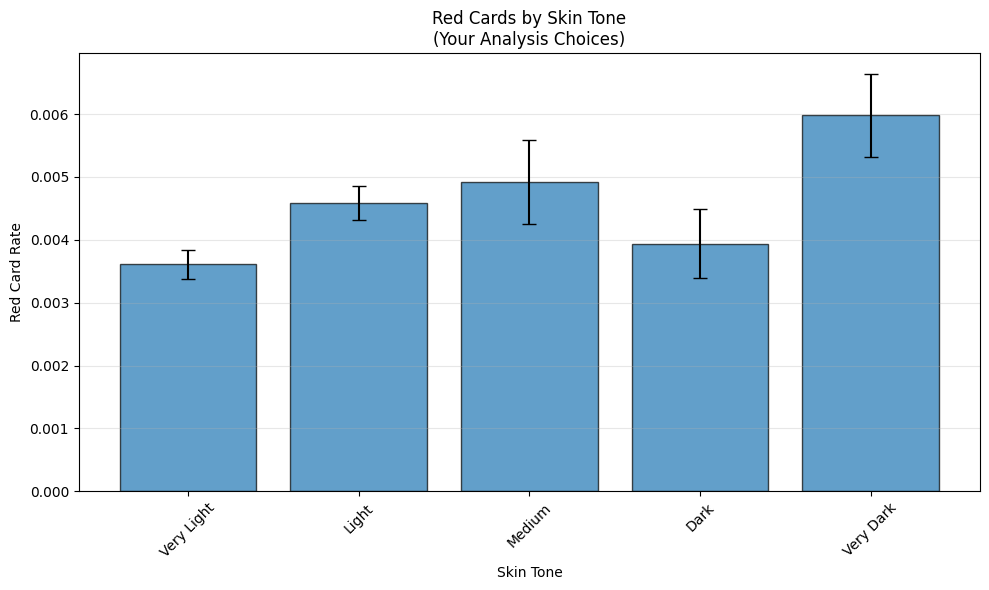

In [ ]:
# visualize the relationship
plt.figure(figsize=(10, 6))

# create bins for visualization
df_final['skin_tone_bin'] = pd.cut(df_final['skin_tone'], bins=5, labels=['Very Light', 'Light', 'Medium', 'Dark', 'Very Dark'])
summary = df_final.groupby('skin_tone_bin')[OUTCOME].agg(['mean', 'sem']).reset_index()

# bar plot with error bars
x_pos = range(len(summary))
plt.bar(x_pos, summary['mean'], yerr=summary['sem'], capsize=5, alpha=0.7, edgecolor='black')
plt.xticks(x_pos, summary['skin_tone_bin'], rotation=45)
plt.xlabel('Skin Tone')
plt.ylabel(f'{OUTCOME.replace("_", " ").title()}')
plt.title('Red Cards by Skin Tone\n(Your Analysis Choices)')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Part 6: Systematic Sensitivity Analysis - The Multiverse of Results

You've tried a few specifications manually. Now let's be **systematic** and explore **all reasonable combinations** of judgment calls.

This is called a **"multiverse analysis"** or **"specification curve analysis"**. We'll:
1. Loop through all combinations of reasonable choices
2. Run the analysis for each combination
3. Visualize how much the results vary
4. Identify which choices matter most

This shows the **full range of defensible conclusions** from the same dataset!

In [ ]:
from itertools import product
import warnings
warnings.filterwarnings('ignore')  # suppress convergence warnings for cleaner output

# define all reasonable choices for each decision
choices = {
    'exclude_goalkeepers': [True, False],
    'min_games': [0, 10, 20],
    'require_both_raters': [True, False],
    'outcome': ['redCards', 'red_card_rate', 'any_red_card'],
    'control_position': [True, False],
    'control_league': [True, False],
    'control_physical': [True, False]
}

# calculate total number of specifications
total_specs = 1
for v in choices.values():
    total_specs *= len(v)

Running 288 different specifications...
This may take a minute or two...\n


In [ ]:
# function to run one specification
def run_specification(exclude_gk, min_games, require_both, outcome, ctrl_pos, ctrl_league, ctrl_phys):
    """
    Run a single regression specification and return results.
    """
    # apply data cleaning choices
    df_spec = df_player.copy()
    
    # exclusions
    if exclude_gk:
        df_spec = df_spec[df_spec['position'] != 'Goalkeeper']
    
    if min_games > 0:
        df_spec = df_spec[df_spec['games'] >= min_games]
    
    if require_both:
        df_spec = df_spec.dropna(subset=['rater1', 'rater2'])
    else:
        df_spec = df_spec.dropna(subset=['skin_tone'])
    
    # build formula
    formula_parts = [outcome + ' ~ skin_tone']
    if ctrl_pos:
        formula_parts.append('C(position)')
    if ctrl_league:
        formula_parts.append('C(leagueCountry)')
    if ctrl_phys:
        formula_parts.append('height + weight')
    
    formula = ' + '.join(formula_parts)
    
    # drop missing values
    analysis_vars = ['skin_tone', outcome]
    if ctrl_pos:
        analysis_vars.append('position')
    if ctrl_league:
        analysis_vars.append('leagueCountry')
    if ctrl_phys:
        analysis_vars.extend(['height', 'weight'])
    
    df_spec = df_spec.dropna(subset=analysis_vars)
    
    # check if we have enough data
    if len(df_spec) < 50:
        return None
    
    try:
        # run regression
        if outcome == 'any_red_card':
            model = smf.logit(formula, data=df_spec).fit(disp=0)
        else:
            model = smf.ols(formula, data=df_spec).fit()
        
        # extract results
        coef = model.params['skin_tone']
        pval = model.pvalues['skin_tone']
        se = model.bse['skin_tone']
        ci_lower = coef - 1.96 * se
        ci_upper = coef + 1.96 * se
        
        # for logistic regression, convert to odds ratio
        if outcome == 'any_red_card':
            odds_ratio = np.exp(coef)
            or_ci_lower = np.exp(ci_lower)
            or_ci_upper = np.exp(ci_upper)
        else:
            odds_ratio = None
            or_ci_lower = None
            or_ci_upper = None
        
        return {
            'coef': coef,
            'se': se,
            'pval': pval,
            'ci_lower': ci_lower,
            'ci_upper': ci_upper,
            'odds_ratio': odds_ratio,
            'or_ci_lower': or_ci_lower,
            'or_ci_upper': or_ci_upper,
            'n': len(df_spec),
            'significant': pval < 0.05
        }
    except:
        return None

# run all specifications
results = []
spec_counter = 0

for combo in product(*choices.values()):
    spec_counter += 1
    if spec_counter % 50 == 0:
        print(f"  Progress: {spec_counter}/{total_specs}")
    
    exclude_gk, min_games, require_both, outcome, ctrl_pos, ctrl_league, ctrl_phys = combo
    
    result = run_specification(exclude_gk, min_games, require_both, outcome, 
                               ctrl_pos, ctrl_league, ctrl_phys)
    
    if result is not None:
        results.append({
            'exclude_goalkeepers': exclude_gk,
            'min_games': min_games,
            'require_both_raters': require_both,
            'outcome': outcome,
            'control_position': ctrl_pos,
            'control_league': ctrl_league,
            'control_physical': ctrl_phys,
            **result
        })

# convert to DataFrame
results_df = pd.DataFrame(results)

print(f"\nCompleted! Successfully ran {len(results_df):,} specifications.")
print(f"({total_specs - len(results_df)} specifications failed due to insufficient data)")

  Progress: 50/288
  Progress: 100/288
  Progress: 150/288
  Progress: 200/288
  Progress: 250/288

Completed! Successfully ran 288 specifications.
(0 specifications failed due to insufficient data)


In [ ]:
# summary statistics
print("="*80)
print("MULTIVERSE ANALYSIS RESULTS")
print("="*80)
print()
print(f"Total specifications: {len(results_df):,}")
print()
print("Statistical Significance:")
print(f"  Significant (p < 0.05):     {results_df['significant'].sum():,} ({results_df['significant'].mean()*100:.1f}%)")
print(f"  Not significant (p >= 0.05): {(~results_df['significant']).sum():,} ({(~results_df['significant']).mean()*100:.1f}%)")
print()
print("Coefficient Range (across all outcomes):")
print(f"  Minimum: {results_df['coef'].min():.4f}")
print(f"  Maximum: {results_df['coef'].max():.4f}")
print(f"  Mean:    {results_df['coef'].mean():.4f}")
print(f"  Median:  {results_df['coef'].median():.4f}")
print()
print("Odds Ratios (for logistic regression specs only):")
logistic_specs = results_df[results_df['outcome'] == 'any_red_card']
if len(logistic_specs) > 0:
    print(f"  Minimum: {logistic_specs['odds_ratio'].min():.3f}")
    print(f"  Maximum: {logistic_specs['odds_ratio'].max():.3f}")
    print(f"  Mean:    {logistic_specs['odds_ratio'].mean():.3f}")
    print(f"  Median:  {logistic_specs['odds_ratio'].median():.3f}")

MULTIVERSE ANALYSIS RESULTS

Total specifications: 288

Statistical Significance:
  Significant (p < 0.05):     118 (41.0%)
  Not significant (p >= 0.05): 170 (59.0%)

Coefficient Range (across all outcomes):
  Minimum: 0.0012
  Maximum: 0.4508
  Mean:    0.1382
  Median:  0.1088

Odds Ratios (for logistic regression specs only):
  Minimum: 1.051
  Maximum: 1.570
  Mean:    1.291
  Median:  1.301


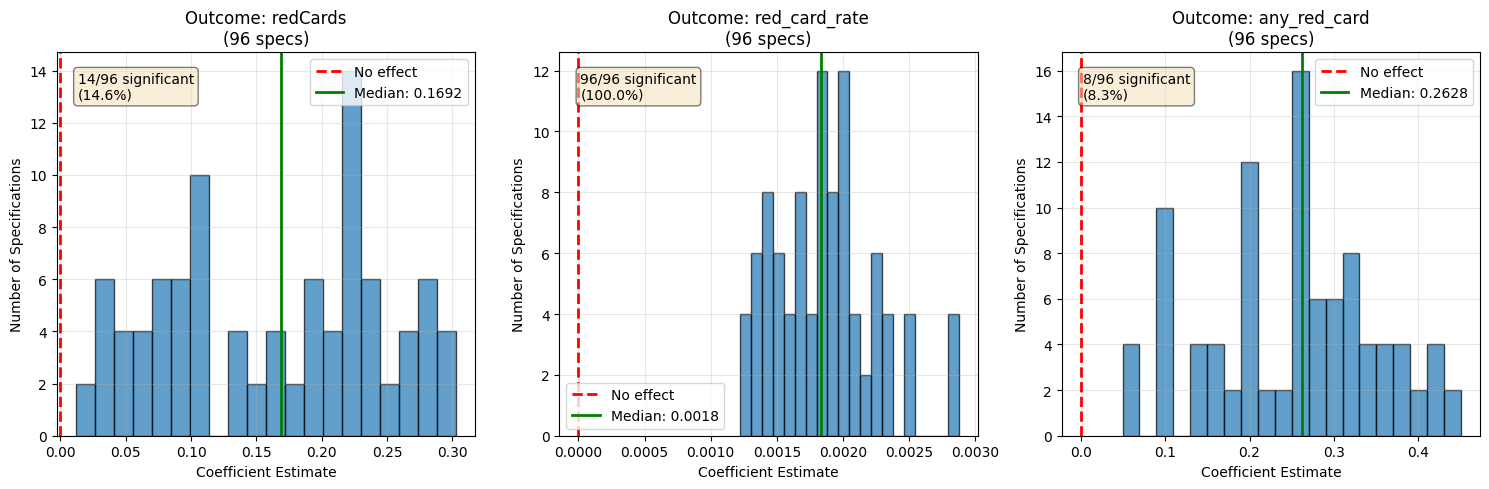

In [ ]:
# visualization 1: Distribution of coefficient estimates by outcome type
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, outcome_type in enumerate(['redCards', 'red_card_rate', 'any_red_card']):
    outcome_data = results_df[results_df['outcome'] == outcome_type]
    
    axes[idx].hist(outcome_data['coef'], bins=20, edgecolor='black', alpha=0.7)
    axes[idx].axvline(0, color='red', linestyle='--', linewidth=2, label='No effect')
    axes[idx].axvline(outcome_data['coef'].median(), color='green', linestyle='-', 
                     linewidth=2, label=f'Median: {outcome_data["coef"].median():.4f}')
    axes[idx].set_xlabel('Coefficient Estimate')
    axes[idx].set_ylabel('Number of Specifications')
    axes[idx].set_title(f'Outcome: {outcome_type}\n({len(outcome_data)} specs)')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
    
    # add significance info
    n_sig = outcome_data['significant'].sum()
    pct_sig = n_sig / len(outcome_data) * 100
    axes[idx].text(0.05, 0.95, f'{n_sig}/{len(outcome_data)} significant\n({pct_sig:.1f}%)',
                  transform=axes[idx].transAxes, verticalalignment='top',
                  bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

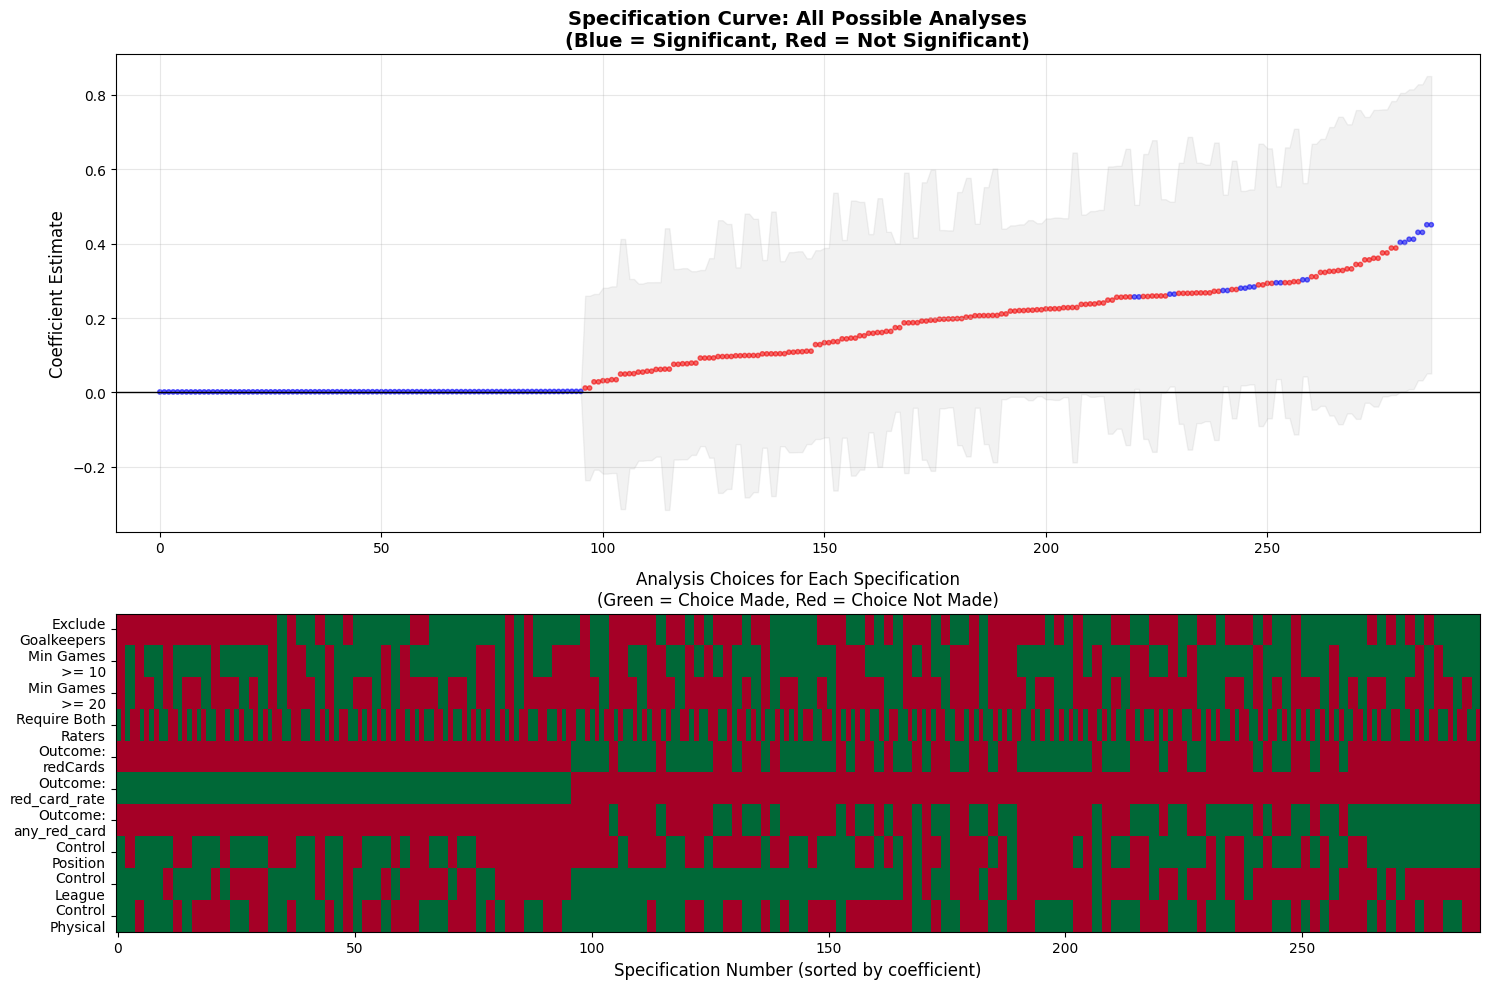

In [ ]:
# visualization 2: Specification curve plot
# sort specifications by coefficient estimate
results_sorted = results_df.sort_values('coef').reset_index(drop=True)
results_sorted['spec_number'] = range(len(results_sorted))

fig, axes = plt.subplots(2, 1, figsize=(15, 10), height_ratios=[3, 2])

# top panel: Coefficient estimates with confidence intervals
colors = ['red' if not sig else 'blue' for sig in results_sorted['significant']]
axes[0].scatter(results_sorted['spec_number'], results_sorted['coef'], 
               c=colors, alpha=0.6, s=10)
axes[0].axhline(0, color='black', linestyle='-', linewidth=1)
axes[0].set_ylabel('Coefficient Estimate', fontsize=12)
axes[0].set_title('Specification Curve: All Possible Analyses\n(Blue = Significant, Red = Not Significant)', 
                 fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(-10, len(results_sorted) + 10)

# add shaded region for confidence
axes[0].fill_between(results_sorted['spec_number'], 
                     results_sorted['ci_lower'], 
                     results_sorted['ci_upper'], 
                     alpha=0.1, color='gray')

# bottom panel: Which choices were made for each specification
choice_labels = [
    'Exclude\nGoalkeepers',
    'Min Games\n>= 10',
    'Min Games\n>= 20',
    'Require Both\nRaters',
    'Outcome:\nredCards',
    'Outcome:\nred_card_rate',
    'Outcome:\nany_red_card',
    'Control\nPosition',
    'Control\nLeague',
    'Control\nPhysical'
]

choice_values = []
for idx, row in results_sorted.iterrows():
    values = [
        row['exclude_goalkeepers'],
        row['min_games'] >= 10,
        row['min_games'] >= 20,
        row['require_both_raters'],
        row['outcome'] == 'redCards',
        row['outcome'] == 'red_card_rate',
        row['outcome'] == 'any_red_card',
        row['control_position'],
        row['control_league'],
        row['control_physical']
    ]
    choice_values.append(values)

choice_matrix = np.array(choice_values).T
axes[1].imshow(choice_matrix, aspect='auto', cmap='RdYlGn', interpolation='nearest')
axes[1].set_yticks(range(len(choice_labels)))
axes[1].set_yticklabels(choice_labels, fontsize=10)
axes[1].set_xlabel('Specification Number (sorted by coefficient)', fontsize=12)
axes[1].set_title('Analysis Choices for Each Specification\n(Green = Choice Made, Red = Choice Not Made)', 
                 fontsize=12)

plt.tight_layout()
plt.show()

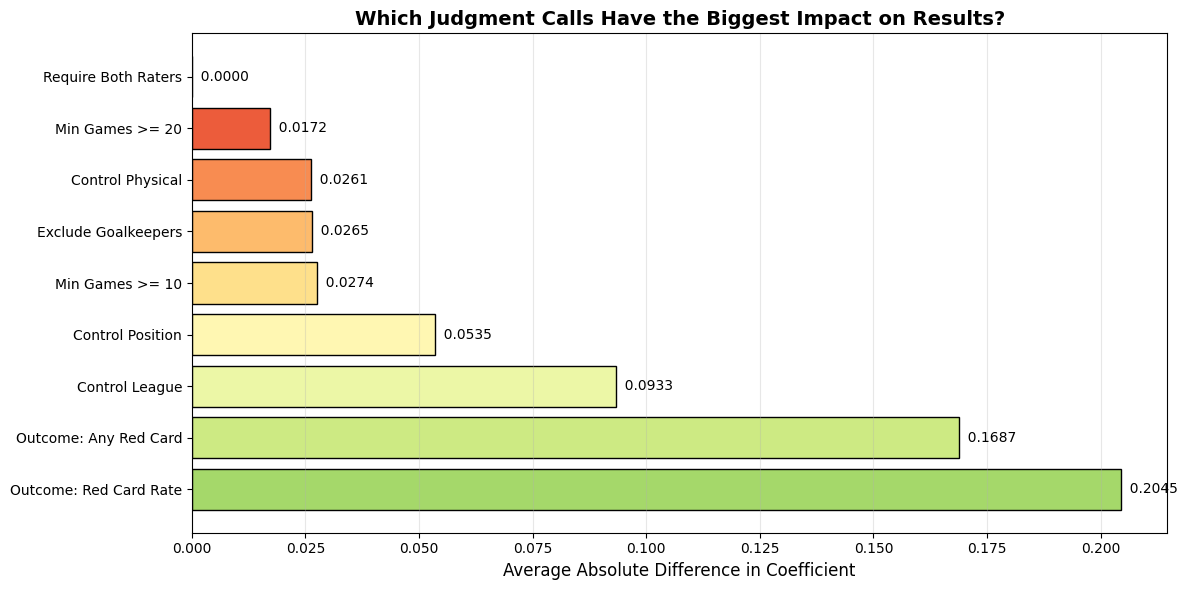


Choice Impact Ranking (biggest to smallest):
  1. Outcome: Red Card Rate: 0.2045
  2. Outcome: Any Red Card: 0.1687
  3. Control League: 0.0933
  4. Control Position: 0.0535
  5. Min Games >= 10: 0.0274
  6. Exclude Goalkeepers: 0.0265
  7. Control Physical: 0.0261
  8. Min Games >= 20: 0.0172
  9. Require Both Raters: 0.0000


In [ ]:
# visualization 3: Which choices matter most?
# calculate average coefficient difference for each choice

choice_impact = {}

# for binary choices
for choice in ['exclude_goalkeepers', 'require_both_raters', 'control_position', 
               'control_league', 'control_physical']:
    made_choice = results_df[results_df[choice] == True]['coef']
    not_made = results_df[results_df[choice] == False]['coef']
    if len(made_choice) > 0 and len(not_made) > 0:
        diff = abs(made_choice.mean() - not_made.mean())
        choice_impact[choice] = diff

# for min_games
for threshold in [10, 20]:
    above = results_df[results_df['min_games'] >= threshold]['coef']
    below = results_df[results_df['min_games'] < threshold]['coef']
    if len(above) > 0 and len(below) > 0:
        diff = abs(above.mean() - below.mean())
        choice_impact[f'min_games >= {threshold}'] = diff

# for outcome type (compare to baseline)
for outcome in ['red_card_rate', 'any_red_card']:
    this_outcome = results_df[results_df['outcome'] == outcome]['coef']
    other_outcomes = results_df[results_df['outcome'] != outcome]['coef']
    if len(this_outcome) > 0 and len(other_outcomes) > 0:
        diff = abs(this_outcome.mean() - other_outcomes.mean())
        choice_impact[f'outcome: {outcome}'] = diff

# sort by impact
choice_impact_sorted = dict(sorted(choice_impact.items(), key=lambda x: x[1], reverse=True))

# plot
plt.figure(figsize=(12, 6))
labels = [k.replace('_', ' ').title() for k in choice_impact_sorted.keys()]
values = list(choice_impact_sorted.values())
colors_impact = plt.cm.RdYlGn_r(np.linspace(0.3, 0.9, len(values)))

bars = plt.barh(labels, values, color=colors_impact, edgecolor='black')
plt.xlabel('Average Absolute Difference in Coefficient', fontsize=12)
plt.title('Which Judgment Calls Have the Biggest Impact on Results?', 
         fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')

# add value labels
for i, (bar, val) in enumerate(zip(bars, values)):
    plt.text(val, i, f'  {val:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\nChoice Impact Ranking (biggest to smallest):")
for i, (choice, impact) in enumerate(choice_impact_sorted.items(), 1):
    print(f"  {i}. {choice.replace('_', ' ').title()}: {impact:.4f}")

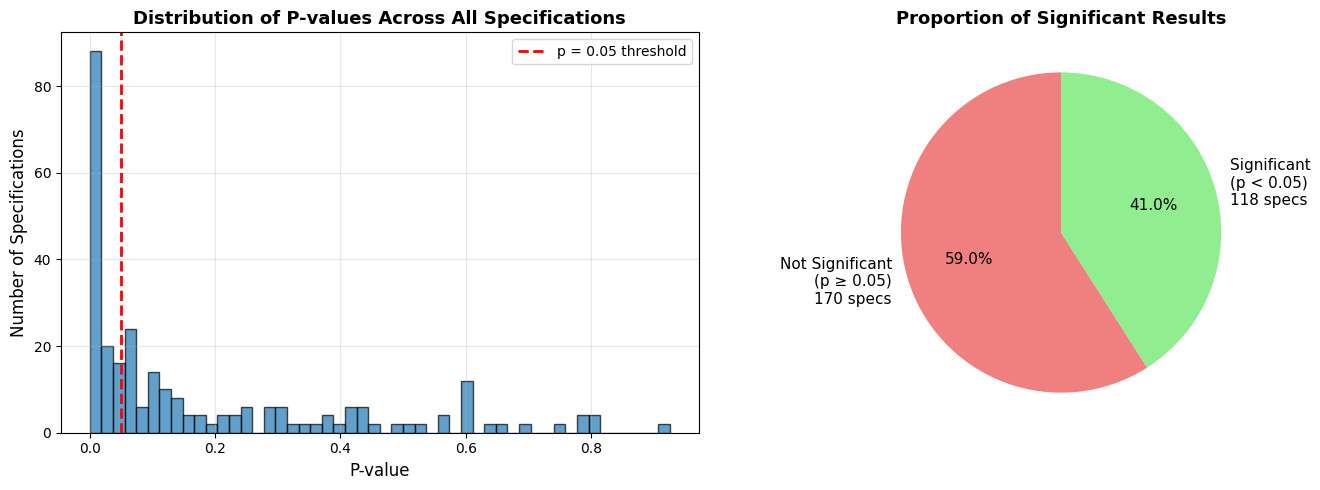

In [ ]:
# final summary visualization: P-value distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram of p-values
axes[0].hist(results_df['pval'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(0.05, color='red', linestyle='--', linewidth=2, label='p = 0.05 threshold')
axes[0].set_xlabel('P-value', fontsize=12)
axes[0].set_ylabel('Number of Specifications', fontsize=12)
axes[0].set_title('Distribution of P-values Across All Specifications', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# pie chart of significance
sig_counts = results_df['significant'].value_counts()
colors_pie = ['lightcoral', 'lightgreen']
labels_pie = [f'Not Significant\n(p ≥ 0.05)\n{sig_counts[False]} specs', 
              f'Significant\n(p < 0.05)\n{sig_counts[True]} specs']
axes[1].pie([sig_counts[False], sig_counts[True]], labels=labels_pie, 
           colors=colors_pie, autopct='%1.1f%%', startangle=90, 
           textprops={'fontsize': 11})
axes[1].set_title('Proportion of Significant Results', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

### What Does This Tell Us?

The multiverse analysis reveals:

1. **Results are sensitive to choices**: The coefficient estimates and p-values vary substantially across specifications

2. **Some choices matter more than others**: The bar chart shows which judgment calls have the biggest impact on results

3. **Statistical significance varies**: Depending on your choices, you might or might not find a "significant" result

4. **Most choices are defensible**: Each specification represents a reasonable analytical decision that a qualified team chose

This is exactly what Silberzahn et al. found: **different reasonable analysts reach different conclusions from the same data**.

## Part 7: Try It Yourself - Manual Sensitivity Analysis

Now go back to Part 5 and change your decisions manually! Try:

1. **Conservative approach:** Exclude goalkeepers, require 20+ games, both raters, many controls
2. **Inclusive approach:** Keep everyone, 0 games minimum, one rater OK, minimal controls
3. **Different outcomes:** Compare using `redCards` vs `red_card_rate` vs `any_red_card`

### Questions to ponder:

1. **How much do your results change?**

2. **What would you report?**
   - If you were asked to do a similar analysis in your job,
     how would you answer the question? What would you include as evidence?

3. **What does this teach us about data science?**